# Notebook 05 — Exploratory Data Analysis
## Section 1: Delay Distribution (Regression Focus, Multi-Month)

Load merged data from disk and profile the continuous target `delay_in_min`.

**Focus**
- Mean / median / percentiles of delay (minutes)
- Early vs late as **description only** (not a classification task)
- Primary ML metric later: **MAE**

**Data:** `ice_weather_merged_YYYY-MM.parquet` (Jul / Aug / Sep)

**Next:** Section 2 — weather vs delay.

Notebook 05 | Section 1 — Delay distribution (regression)
Target : delay_in_min
Metric : MAE (later notebooks)
Months : 2024-07, 2024-08, 2024-09

Loading from disk: ice_weather_merged_2024-07.parquet
Loading from disk: ice_weather_merged_2024-08.parquet
Loading from disk: ice_weather_merged_2024-09.parquet
Total merged rows: 418,257

--- SUBSETS ---
  All rows             : 418,257
  Mergeable            : 377,055
  Weather-matched (EDA): 377,026

TARGET `delay_in_min` (weather-matched rows)
  mean   = 10.85 min
  median = 4.0 min
  std    = 18.53 min
  range  = [-66, 391] min
  p90    = 30.0 | p95 = 45.0

  Descriptive shares (NOT a classification task):
    early (<0)     : 1.68%
    exact 0        : 19.35%
    late  (>0)     : 78.97%
    late ≥6 min    : 42.7%  (info only)

Month               n     mean   median      p90
2024-07       132,268     10.6      4.0     30.0
2024-08       122,794     11.5      4.0     31.0
2024-09       121,964     10.5      4.0     29.0

--- Naive refe

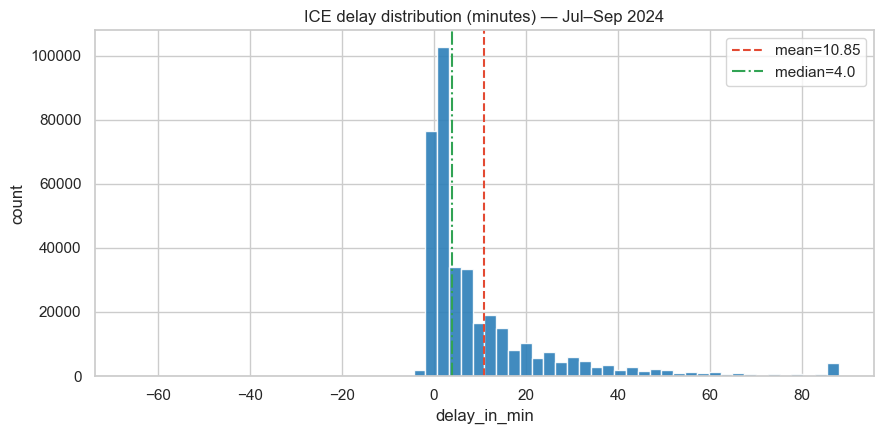

Saved figure: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures\eda_delay_histogram_multi_month.png


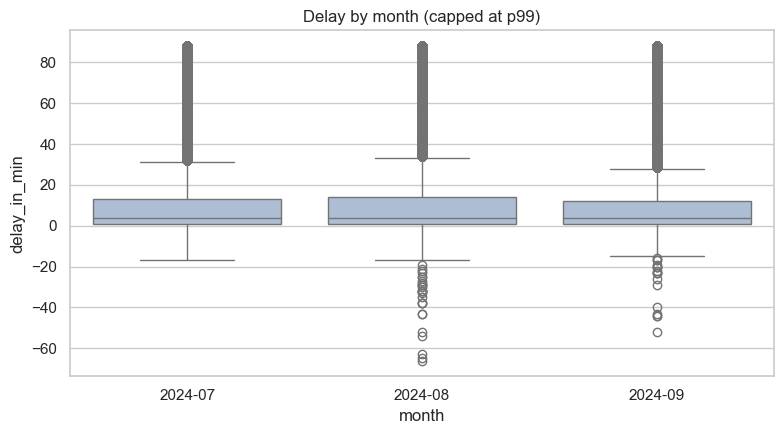

Saved figure: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures\eda_delay_by_month.png

Section 1 COMPLETE
Report: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\reference\eda_delay_report_multi_month.json
Next: Section 2 — weather variables vs delay_in_min


In [1]:
# =============================================================================
# Notebook 05 | Section 1: Delay Distribution (Regression, Multi-Month)
# =============================================================================
# Load ice_weather_merged_*.parquet from disk. Profile delay_in_min.
# No classification target. Saves report + histogram figures.
# =============================================================================

from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        config_file = candidate / "data" / "reference" / "project_config.json"
        if config_file.exists():
            return candidate
        nb = candidate / "Notebooks"
        if (nb / "data" / "reference" / "project_config.json").exists():
            return nb
    raise FileNotFoundError("Cannot find data/reference/project_config.json")


PROJECT_ROOT = find_project_root()
REFERENCE_DIR = PROJECT_ROOT / "data" / "reference"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROCESSED_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_PATH = REFERENCE_DIR / "project_config.json"
RESEARCH_PATH = REFERENCE_DIR / "research_framework.json"
EDA_REPORT_PATH = REFERENCE_DIR / "eda_delay_report_multi_month.json"
HIST_PNG = FIGURES_DIR / "eda_delay_histogram_multi_month.png"
MONTHLY_PNG = FIGURES_DIR / "eda_delay_by_month.png"

sns.set_theme(style="whitegrid", font_scale=1.0)


def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if pd.isna(obj):
        return None
    return obj


def delay_stats(series: pd.Series) -> dict:
    s = series.dropna()
    return {
        "count": int(len(s)),
        "mean": round(float(s.mean()), 2),
        "median": round(float(s.median()), 2),
        "std": round(float(s.std()), 2),
        "min": int(s.min()),
        "max": int(s.max()),
        "p25": round(float(s.quantile(0.25)), 2),
        "p75": round(float(s.quantile(0.75)), 2),
        "p90": round(float(s.quantile(0.90)), 2),
        "p95": round(float(s.quantile(0.95)), 2),
        "early_pct": round(100 * (s < 0).mean(), 2),
        "zero_pct": round(100 * (s == 0).mean(), 2),
        "late_pct": round(100 * (s > 0).mean(), 2),
        "late_ge_6_pct": round(100 * (s >= 6).mean(), 2),  # descriptive only
    }


config = load_json(CONFIG_PATH)
research = load_json(RESEARCH_PATH)
TARGET_MONTHS = config["scope"]["target_months"]
PRIMARY_TARGET = config["ml_tasks"]["primary"]["target"]
PRIMARY_METRIC = config["ml_tasks"]["primary"]["primary_metric"]

print("Notebook 05 | Section 1 — Delay distribution (regression)")
print(f"Target : {PRIMARY_TARGET}")
print(f"Metric : {PRIMARY_METRIC.upper()} (later notebooks)")
print(f"Months : {', '.join(TARGET_MONTHS)}")
print()

# =============================================================================
# LOAD ALL MERGED MONTHS FROM DISK
# =============================================================================
frames = []
for month in TARGET_MONTHS:
    path = PROCESSED_DIR / f"ice_weather_merged_{month}.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}\nRun Notebook 04 first.")
    print(f"Loading from disk: {path.name}")
    part = pd.read_parquet(path)
    part["month"] = month
    frames.append(part)

df = pd.concat(frames, ignore_index=True)
print(f"Total merged rows: {len(df):,}")
print()

# Analysis subset: mergeable + weather-matched (fair for weather EDA next)
if "mergeable" in df.columns:
    mergeable = df[df["mergeable"]].copy()
else:
    mergeable = df[df["departure_planned_hour_naive"].notna()].copy()

if "weather_matched" in mergeable.columns:
    analysis_df = mergeable[mergeable["weather_matched"]].copy()
else:
    analysis_df = mergeable[mergeable["temperature_2m"].notna()].copy()

print("--- SUBSETS ---")
print(f"  All rows             : {len(df):,}")
print(f"  Mergeable            : {len(mergeable):,}")
print(f"  Weather-matched (EDA): {len(analysis_df):,}")
print()

# =============================================================================
# DELAY STATS — overall + per month
# =============================================================================
overall = delay_stats(analysis_df[PRIMARY_TARGET])
by_month = {
    m: delay_stats(analysis_df.loc[analysis_df["month"] == m, PRIMARY_TARGET])
    for m in TARGET_MONTHS
}

print("=" * 72)
print(f"TARGET `{PRIMARY_TARGET}` (weather-matched rows)")
print("=" * 72)
print(f"  mean   = {overall['mean']} min")
print(f"  median = {overall['median']} min")
print(f"  std    = {overall['std']} min")
print(f"  range  = [{overall['min']}, {overall['max']}] min")
print(f"  p90    = {overall['p90']} | p95 = {overall['p95']}")
print()
print("  Descriptive shares (NOT a classification task):")
print(f"    early (<0)     : {overall['early_pct']}%")
print(f"    exact 0        : {overall['zero_pct']}%")
print(f"    late  (>0)     : {overall['late_pct']}%")
print(f"    late ≥6 min    : {overall['late_ge_6_pct']}%  (info only)")
print()

print(f"{'Month':<10} {'n':>10} {'mean':>8} {'median':>8} {'p90':>8}")
for m in TARGET_MONTHS:
    s = by_month[m]
    print(
        f"{m:<10} {s['count']:>10,} {s['mean']:>8.1f} "
        f"{s['median']:>8.1f} {s['p90']:>8.1f}"
    )
print()

# Naive MAE baselines (what a constant predictor would score)
mean_pred = overall["mean"]
median_pred = overall["median"]
y = analysis_df[PRIMARY_TARGET]
naive_mae_mean = round(float(np.mean(np.abs(y - mean_pred))), 2)
naive_mae_median = round(float(np.mean(np.abs(y - median_pred))), 2)
print("--- Naive reference (not a model yet) ---")
print(f"  MAE if always predict mean   ({mean_pred}): {naive_mae_mean} min")
print(f"  MAE if always predict median ({median_pred}): {naive_mae_median} min")
print()

# =============================================================================
# PLOTS
# =============================================================================
# 1) Histogram of delay (capped for readability)
cap = float(analysis_df[PRIMARY_TARGET].quantile(0.99))
plot_delay = analysis_df[PRIMARY_TARGET].clip(upper=cap)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(plot_delay, bins=60, color="#2c7fb8", edgecolor="white", alpha=0.9)
ax.axvline(overall["mean"], color="#e34a33", linestyle="--", label=f"mean={overall['mean']}")
ax.axvline(overall["median"], color="#31a354", linestyle="-.", label=f"median={overall['median']}")
ax.set_title("ICE delay distribution (minutes) — Jul–Sep 2024")
ax.set_xlabel("delay_in_min")
ax.set_ylabel("count")
ax.legend()
fig.tight_layout()
fig.savefig(HIST_PNG, dpi=120)
plt.show()
print(f"Saved figure: {HIST_PNG}")

# 2) Boxplot by month
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    data=analysis_df.assign(
        delay_plot=analysis_df[PRIMARY_TARGET].clip(upper=cap)
    ),
    x="month",
    y="delay_plot",
    ax=ax,
    color="#a6bddb",
)
ax.set_title("Delay by month (capped at p99)")
ax.set_ylabel("delay_in_min")
fig.tight_layout()
fig.savefig(MONTHLY_PNG, dpi=120)
plt.show()
print(f"Saved figure: {MONTHLY_PNG}")
print()

# =============================================================================
# SAVE REPORT
# =============================================================================
report = {
    "metadata": {
        "notebook": "05_Exploratory_Data_Analysis",
        "section": "Section 1",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "target_months": TARGET_MONTHS,
        "primary_target": PRIMARY_TARGET,
        "primary_metric": PRIMARY_METRIC,
        "task_type": "regression",
        "loaded_from_disk": [
            str(PROCESSED_DIR / f"ice_weather_merged_{m}.parquet")
            for m in TARGET_MONTHS
        ],
        "note": "Classification is not in scope; late≥6% is descriptive only.",
    },
    "subsets": {
        "all_rows": int(len(df)),
        "mergeable_rows": int(len(mergeable)),
        "weather_matched_rows": int(len(analysis_df)),
    },
    "delay_stats_overall": overall,
    "delay_stats_by_month": by_month,
    "naive_mae_reference": {
        "mae_mean_predictor": naive_mae_mean,
        "mae_median_predictor": naive_mae_median,
        "note": research["regression"]["naive_baselines"],
    },
    "figures": {
        "histogram": str(HIST_PNG),
        "by_month": str(MONTHLY_PNG),
    },
}

with EDA_REPORT_PATH.open("w", encoding="utf-8") as f:
    json.dump(make_json_safe(report), f, indent=2, ensure_ascii=False)

sep = "=" * 72
print(sep)
print("Section 1 COMPLETE")
print(sep)
print(f"Report: {EDA_REPORT_PATH}")
print("Next: Section 2 — weather variables vs delay_in_min")
print(sep)

# Notebook 05 — Exploratory Data Analysis
## Section 2: Weather vs Delay (Regression Focus)

Relate Open-Meteo weather variables to continuous target `delay_in_min`.

**What we do**
1. Load merged Parquets from disk (Jul–Sep)
2. Correlate weather columns vs `delay_in_min`
3. Bin a few weather variables → mean delay per bin
4. Save report + figures

**Answers RQ3 / H1–H2** (association only — not yet causation or models).

**Next:** Section 3 — EDA close-out.

Notebook 05 | Section 2 — Weather vs delay (regression)
Target : delay_in_min | Metric later: MAE
Months : 2024-07, 2024-08, 2024-09

Loading: ice_weather_merged_2024-07.parquet
Loading: ice_weather_merged_2024-08.parquet
Loading: ice_weather_merged_2024-09.parquet
EDA rows (weather-matched): 377,026

Pearson correlation vs `delay_in_min`
Variable                      r
  temperature_2m        +0.0928
  windspeed_10m         -0.0115
  precipitation         +0.0021
  rain                  +0.0021
  windgusts_10m         +0.0019
  weather_code          +0.0015
  snowfall                  nan
  visibility                nan

Note: |r| near 0 = weak linear link; EDA only, not a model.

Mean delay by weather quartile bins

precipitation
     bin_label      n  mean_feature  mean_delay  median_delay
(-0.001, 17.2] 377026         0.112       10.85           4.0

windgusts_10m
    bin_label     n  mean_feature  mean_delay  median_delay
(1.399, 15.5] 94912        11.528       10.71           3.0

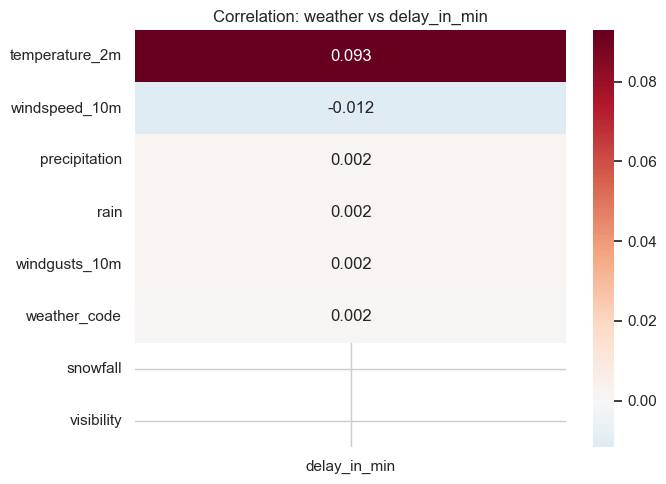

Saved: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures\eda_weather_corr_heatmap.png


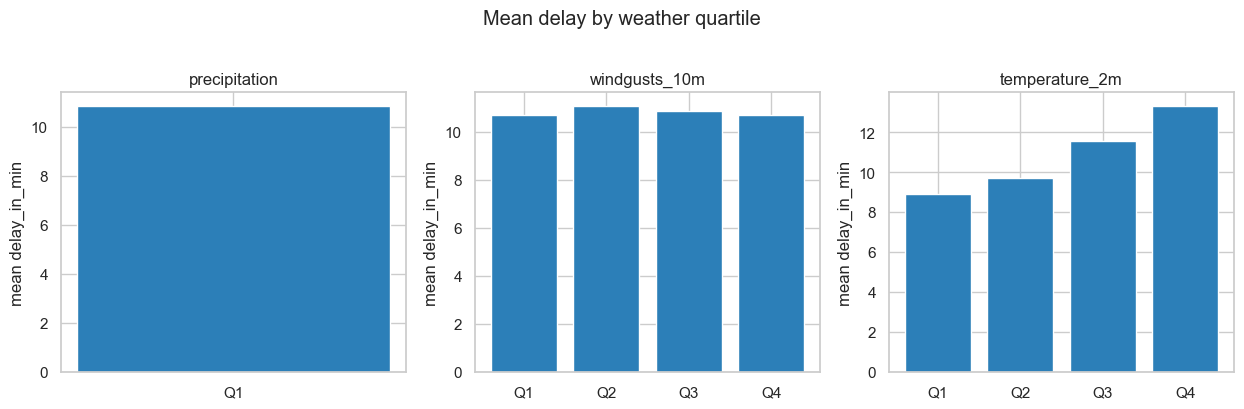

Saved: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures\eda_weather_bins_mean_delay.png


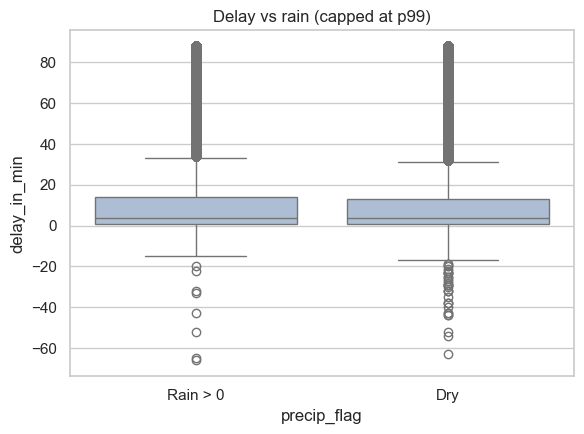

Saved: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures\eda_precip_boxplot_delay.png

EDA hypothesis hints (not final proof)
  H1 precip: rainy mean delay higher? True
  H2 wind:   positive corr with delay? True

Section 2 COMPLETE
Report: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\reference\eda_weather_report_multi_month.json
Next: Section 3 — Notebook 05 close-out


In [3]:
# =============================================================================
# Notebook 05 | Section 2: Weather vs Delay (Regression, Multi-Month)
# =============================================================================
# Correlations + binned mean delay vs weather. No classification target.
# Fixed: pandas Interval from qcut is converted for JSON save.
# =============================================================================

from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        config_file = candidate / "data" / "reference" / "project_config.json"
        if config_file.exists():
            return candidate
        nb = candidate / "Notebooks"
        if (nb / "data" / "reference" / "project_config.json").exists():
            return nb
    raise FileNotFoundError("Cannot find data/reference/project_config.json")


PROJECT_ROOT = find_project_root()
REFERENCE_DIR = PROJECT_ROOT / "data" / "reference"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROCESSED_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_PATH = REFERENCE_DIR / "project_config.json"
RESEARCH_PATH = REFERENCE_DIR / "research_framework.json"
EDA_WX_REPORT = REFERENCE_DIR / "eda_weather_report_multi_month.json"

CORR_PNG = FIGURES_DIR / "eda_weather_corr_heatmap.png"
BIN_PNG = FIGURES_DIR / "eda_weather_bins_mean_delay.png"
BOX_PNG = FIGURES_DIR / "eda_precip_boxplot_delay.png"

WEATHER_COLS = [
    "temperature_2m",
    "precipitation",
    "rain",
    "snowfall",
    "windspeed_10m",
    "windgusts_10m",
    "weather_code",
    "visibility",
]

sns.set_theme(style="whitegrid", font_scale=1.0)


def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def make_json_safe(obj):
    """Convert numpy/pandas types (incl. Interval) to JSON-safe Python types."""
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, pd.Interval):
        return str(obj)
    # Timestamp / datetime
    if isinstance(obj, (pd.Timestamp, datetime)):
        return obj.isoformat()
    try:
        if pd.isna(obj):
            return None
    except (ValueError, TypeError):
        pass
    return obj


config = load_json(CONFIG_PATH)
research = load_json(RESEARCH_PATH)
TARGET_MONTHS = config["scope"]["target_months"]
PRIMARY_TARGET = config["ml_tasks"]["primary"]["target"]
PRIMARY_METRIC = config["ml_tasks"]["primary"]["primary_metric"]

print("Notebook 05 | Section 2 — Weather vs delay (regression)")
print(f"Target : {PRIMARY_TARGET} | Metric later: {PRIMARY_METRIC.upper()}")
print(f"Months : {', '.join(TARGET_MONTHS)}")
print()

# =============================================================================
# LOAD MERGED DATA FROM DISK
# =============================================================================
frames = []
for month in TARGET_MONTHS:
    path = PROCESSED_DIR / f"ice_weather_merged_{month}.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}\nRun Notebook 04 first.")
    print(f"Loading: {path.name}")
    part = pd.read_parquet(path)
    part["month"] = month
    frames.append(part)

df = pd.concat(frames, ignore_index=True)

if "mergeable" in df.columns:
    mergeable = df[df["mergeable"]].copy()
else:
    mergeable = df[df["departure_planned_hour_naive"].notna()].copy()

if "weather_matched" in mergeable.columns:
    analysis_df = mergeable[mergeable["weather_matched"]].copy()
else:
    analysis_df = mergeable[mergeable["temperature_2m"].notna()].copy()

print(f"EDA rows (weather-matched): {len(analysis_df):,}")
print()

available_wx = [c for c in WEATHER_COLS if c in analysis_df.columns]
missing_wx = [c for c in WEATHER_COLS if c not in analysis_df.columns]
if missing_wx:
    print(f"Warning — missing weather cols: {missing_wx}")

# =============================================================================
# 1) PEARSON CORRELATIONS vs delay_in_min
# =============================================================================
corr_cols = available_wx + [PRIMARY_TARGET]
corr_matrix = analysis_df[corr_cols].corr(method="pearson")

weather_corr = {}
for var in available_wx:
    r = corr_matrix.loc[var, PRIMARY_TARGET]
    weather_corr[var] = {
        "vs_delay_in_min": None if pd.isna(r) else round(float(r), 4),
        "abs_corr": 0.0 if pd.isna(r) else round(abs(float(r)), 4),
    }

ranked = sorted(
    available_wx,
    key=lambda v: weather_corr[v]["abs_corr"],
    reverse=True,
)

print("=" * 72)
print(f"Pearson correlation vs `{PRIMARY_TARGET}`")
print("=" * 72)
print(f"{'Variable':<20} {'r':>10}")
for var in ranked:
    r = weather_corr[var]["vs_delay_in_min"]
    r_txt = "nan" if r is None else f"{r:+.4f}"
    print(f"  {var:<18} {r_txt:>10}")
print()
print("Note: |r| near 0 = weak linear link; EDA only, not a model.")
print()

# =============================================================================
# 2) BINNED MEAN DELAY (precipitation, wind gusts, temperature)
# =============================================================================
bin_summaries = {}


def binned_mean_delay(col: str, n_bins: int = 4) -> pd.DataFrame:
    """Quartile bins → mean/median delay per bin."""
    s = analysis_df[col]
    if s.nunique(dropna=True) < 2 or s.std(skipna=True) == 0:
        return pd.DataFrame()
    try:
        cats = pd.qcut(s, q=n_bins, duplicates="drop")
    except ValueError:
        return pd.DataFrame()
    out = (
        analysis_df.assign(_bin=cats)
        .groupby("_bin", observed=True)
        .agg(
            n=(PRIMARY_TARGET, "count"),
            mean_delay=(PRIMARY_TARGET, "mean"),
            median_delay=(PRIMARY_TARGET, "median"),
            mean_feature=(col, "mean"),
        )
        .reset_index()
    )
    out["mean_delay"] = out["mean_delay"].round(2)
    out["median_delay"] = out["median_delay"].round(2)
    out["mean_feature"] = out["mean_feature"].round(3)
    out["bin_label"] = out["_bin"].astype(str)
    # Drop Interval column before any JSON conversion
    out = out.drop(columns=["_bin"])
    return out


focus_vars = [
    v for v in ["precipitation", "windgusts_10m", "temperature_2m"] if v in available_wx
]

print("=" * 72)
print("Mean delay by weather quartile bins")
print("=" * 72)
for var in focus_vars:
    table = binned_mean_delay(var)
    bin_summaries[var] = table.to_dict(orient="records") if len(table) else []
    if len(table) == 0:
        print(f"\n{var}: skipped (low variation)")
        continue
    print(f"\n{var}")
    print(
        table[["bin_label", "n", "mean_feature", "mean_delay", "median_delay"]].to_string(
            index=False
        )
    )

# Rain vs no-rain simple split
if "precipitation" in available_wx:
    rainy = analysis_df["precipitation"] > 0
    rain_compare = {
        "dry_hours_mean_delay": round(
            float(analysis_df.loc[~rainy, PRIMARY_TARGET].mean()), 2
        ),
        "rainy_hours_mean_delay": round(
            float(analysis_df.loc[rainy, PRIMARY_TARGET].mean()), 2
        ),
        "dry_n": int((~rainy).sum()),
        "rainy_n": int(rainy.sum()),
    }
    print()
    print("--- Dry vs rainy hours ---")
    print(
        f"  Dry   mean delay: {rain_compare['dry_hours_mean_delay']} min "
        f"(n={rain_compare['dry_n']:,})"
    )
    print(
        f"  Rainy mean delay: {rain_compare['rainy_hours_mean_delay']} min "
        f"(n={rain_compare['rainy_n']:,})"
    )
else:
    rain_compare = {}

print()

# =============================================================================
# 3) PLOTS
# =============================================================================
fig, ax = plt.subplots(figsize=(7, 5))
heat = corr_matrix.loc[available_wx, [PRIMARY_TARGET]].sort_values(
    by=PRIMARY_TARGET, key=lambda s: s.abs(), ascending=False
)
sns.heatmap(heat, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation: weather vs delay_in_min")
fig.tight_layout()
fig.savefig(CORR_PNG, dpi=120)
plt.show()
print(f"Saved: {CORR_PNG}")

n_focus = len([v for v in focus_vars if bin_summaries.get(v)])
if n_focus:
    fig, axes = plt.subplots(1, n_focus, figsize=(4.2 * n_focus, 4), squeeze=False)
    ax_list = axes[0]
    i = 0
    for var in focus_vars:
        table = pd.DataFrame(bin_summaries[var])
        if table.empty:
            continue
        ax = ax_list[i]
        ax.bar(range(len(table)), table["mean_delay"], color="#2c7fb8")
        ax.set_xticks(range(len(table)))
        ax.set_xticklabels([f"Q{j+1}" for j in range(len(table))], rotation=0)
        ax.set_ylabel("mean delay_in_min")
        ax.set_title(var)
        i += 1
    fig.suptitle("Mean delay by weather quartile", y=1.02)
    fig.tight_layout()
    fig.savefig(BIN_PNG, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {BIN_PNG}")

if "precipitation" in available_wx:
    cap = float(analysis_df[PRIMARY_TARGET].quantile(0.99))
    plot_df = analysis_df.copy()
    plot_df["precip_flag"] = np.where(plot_df["precipitation"] > 0, "Rain > 0", "Dry")
    plot_df["delay_plot"] = plot_df[PRIMARY_TARGET].clip(upper=cap)
    fig, ax = plt.subplots(figsize=(6, 4.5))
    sns.boxplot(data=plot_df, x="precip_flag", y="delay_plot", ax=ax, color="#a6bddb")
    ax.set_title("Delay vs rain (capped at p99)")
    ax.set_ylabel("delay_in_min")
    fig.tight_layout()
    fig.savefig(BOX_PNG, dpi=120)
    plt.show()
    print(f"Saved: {BOX_PNG}")

print()

# =============================================================================
# HYPOTHESIS NOTES (EDA level)
# =============================================================================
h_notes = {
    "H1_precipitation": {
        "statement": research["hypotheses"]["H1"]["statement"],
        "corr_precipitation": weather_corr.get("precipitation", {}).get("vs_delay_in_min"),
        "dry_vs_rainy": rain_compare,
        "supported_hint": bool(
            rain_compare
            and rain_compare.get("rainy_hours_mean_delay", 0)
            > rain_compare.get("dry_hours_mean_delay", 0)
        ),
    },
    "H2_windgusts": {
        "statement": research["hypotheses"]["H2"]["statement"],
        "corr_windgusts": weather_corr.get("windgusts_10m", {}).get("vs_delay_in_min"),
        "supported_hint": bool(
            (weather_corr.get("windgusts_10m", {}).get("vs_delay_in_min") or 0) > 0
        ),
    },
}

print("=" * 72)
print("EDA hypothesis hints (not final proof)")
print("=" * 72)
print(f"  H1 precip: rainy mean delay higher? {h_notes['H1_precipitation']['supported_hint']}")
print(f"  H2 wind:   positive corr with delay? {h_notes['H2_windgusts']['supported_hint']}")
print()

# =============================================================================
# SAVE REPORT
# =============================================================================
report = {
    "metadata": {
        "notebook": "05_Exploratory_Data_Analysis",
        "section": "Section 2",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "target_months": TARGET_MONTHS,
        "primary_target": PRIMARY_TARGET,
        "primary_metric": PRIMARY_METRIC,
        "task_type": "regression",
        "n_rows_analyzed": int(len(analysis_df)),
        "note": "No classification; correlations vs delay_in_min only.",
    },
    "weather_correlations": weather_corr,
    "ranked_by_abs_corr": ranked,
    "bin_summaries": bin_summaries,
    "rain_compare": rain_compare,
    "hypothesis_eda_hints": h_notes,
    "figures": {
        "corr_heatmap": str(CORR_PNG),
        "bin_bars": str(BIN_PNG),
        "precip_boxplot": str(BOX_PNG),
    },
}

with EDA_WX_REPORT.open("w", encoding="utf-8") as f:
    json.dump(make_json_safe(report), f, indent=2, ensure_ascii=False)

sep = "=" * 72
print(sep)
print("Section 2 COMPLETE")
print(sep)
print(f"Report: {EDA_WX_REPORT}")
print("Next: Section 3 — Notebook 05 close-out")
print(sep)

# Notebook 05 — Exploratory Data Analysis
## Section 3: EDA Summary & Close-Out

Confirm delay + weather EDA artifacts are on disk and record key findings.

**Next:** Notebook 06 — Feature engineering for regression (MAE).

In [4]:
# =============================================================================
# Notebook 05 | Section 3: EDA Close-Out (Multi-Month)
# =============================================================================
# Verify reports/figures; summarize findings; save notebook_05_summary.json
# =============================================================================

from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        config_file = candidate / "data" / "reference" / "project_config.json"
        if config_file.exists():
            return candidate
        nb = candidate / "Notebooks"
        if (nb / "data" / "reference" / "project_config.json").exists():
            return nb
    raise FileNotFoundError("Cannot find data/reference/project_config.json")


PROJECT_ROOT = find_project_root()
REFERENCE_DIR = PROJECT_ROOT / "data" / "reference"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROCESSED_DIR / "figures"
CONFIG_PATH = REFERENCE_DIR / "project_config.json"


def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj


config = load_json(CONFIG_PATH)
TARGET_MONTHS = config["scope"]["target_months"]
PRIMARY_TARGET = config["ml_tasks"]["primary"]["target"]
PRIMARY_METRIC = config["ml_tasks"]["primary"]["primary_metric"]

print("Notebook 05 | Section 3 — EDA close-out")
print(f"Target : {PRIMARY_TARGET} | Metric: {PRIMARY_METRIC.upper()}")
print(f"Months : {', '.join(TARGET_MONTHS)}")
print()

checklist = []


def check(label: str, path: Path) -> bool:
    ok = path.exists()
    size = path.stat().st_size if ok else 0
    checklist.append(
        {
            "label": label,
            "path": str(path),
            "exists": ok,
            "size_mb": round(size / 1e6, 2) if ok else 0.0,
        }
    )
    status = "OK" if ok else "MISSING"
    size_txt = f"{size / 1e6:.2f} MB" if ok else "—"
    print(f"  [{status}] {label:<48} {size_txt}")
    return ok


print("=" * 72)
print("FILE CHECKLIST")
print("=" * 72)

all_ok = True

# Merged inputs
print("\nMerged data (from Notebook 04)")
for month in TARGET_MONTHS:
    all_ok &= check(
        f"ice_weather_merged_{month}.parquet",
        PROCESSED_DIR / f"ice_weather_merged_{month}.parquet",
    )

# EDA reports
print("\nEDA reports")
all_ok &= check(
    "eda_delay_report_multi_month.json",
    REFERENCE_DIR / "eda_delay_report_multi_month.json",
)
all_ok &= check(
    "eda_weather_report_multi_month.json",
    REFERENCE_DIR / "eda_weather_report_multi_month.json",
)

# Figures
print("\nFigures")
fig_names = [
    "eda_delay_histogram_multi_month.png",
    "eda_delay_by_month.png",
    "eda_weather_corr_heatmap.png",
    "eda_weather_bins_mean_delay.png",
    "eda_precip_boxplot_delay.png",
]
for name in fig_names:
    all_ok &= check(name, FIGURES_DIR / name)

# ---------------------------------------------------------------------------
# LOAD KEY FINDINGS
# ---------------------------------------------------------------------------
delay_report = load_json(REFERENCE_DIR / "eda_delay_report_multi_month.json")
wx_report = load_json(REFERENCE_DIR / "eda_weather_report_multi_month.json")

overall = delay_report["delay_stats_overall"]
naive = delay_report["naive_mae_reference"]
corr = wx_report["weather_correlations"]
ranked = wx_report["ranked_by_abs_corr"]
rain = wx_report.get("rain_compare", {})
h_notes = wx_report.get("hypothesis_eda_hints", {})

top_wx = ranked[0] if ranked else None
top_r = corr.get(top_wx, {}).get("vs_delay_in_min") if top_wx else None

print()
print("=" * 72)
print("KEY FINDINGS")
print("=" * 72)
print(f"  Rows analyzed (weather-matched): {delay_report['subsets']['weather_matched_rows']:,}")
print(f"  Mean delay   : {overall['mean']} min")
print(f"  Median delay : {overall['median']} min")
print(f"  Naive MAE (mean predictor)   : {naive['mae_mean_predictor']} min")
print(f"  Naive MAE (median predictor) : {naive['mae_median_predictor']} min")
print()
print(f"  Strongest weather corr: {top_wx}  r={top_r}")
if rain:
    print(
        f"  Dry mean delay  : {rain.get('dry_hours_mean_delay')} min | "
        f"Rainy: {rain.get('rainy_hours_mean_delay')} min"
    )
print(
    f"  H1 precip hint : {h_notes.get('H1_precipitation', {}).get('supported_hint')}"
)
print(
    f"  H2 wind hint   : {h_notes.get('H2_windgusts', {}).get('supported_hint')}"
)
print()
print("  Takeaway: weather–delay links are weak in Jul–Sep; temperature is clearest.")
print("  Modeling must beat naive median MAE; evaluate with MAE only.")
print()

ready = bool(all_ok)
print("=" * 72)
print(f"Ready for Notebook 06 (features): {'YES' if ready else 'NO'}")
print("=" * 72)
if not ready:
    missing = [c["label"] for c in checklist if not c["exists"]]
    raise FileNotFoundError(f"Missing files: {missing}")

# ---------------------------------------------------------------------------
# SAVE CLOSE-OUT
# ---------------------------------------------------------------------------
summary_path = REFERENCE_DIR / "notebook_05_summary.json"
summary = {
    "metadata": {
        "notebook": "05_Exploratory_Data_Analysis",
        "section": "Section 3",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "target_months": TARGET_MONTHS,
        "primary_target": PRIMARY_TARGET,
        "primary_metric": PRIMARY_METRIC,
        "task_type": "regression",
    },
    "checklist": checklist,
    "all_files_ok": ready,
    "key_findings": {
        "weather_matched_rows": delay_report["subsets"]["weather_matched_rows"],
        "delay_mean": overall["mean"],
        "delay_median": overall["median"],
        "naive_mae_median_predictor": naive["mae_median_predictor"],
        "naive_mae_mean_predictor": naive["mae_mean_predictor"],
        "top_weather_variable": top_wx,
        "top_weather_corr": top_r,
        "rain_compare": rain,
        "hypothesis_hints": {
            "H1_precip": h_notes.get("H1_precipitation", {}).get("supported_hint"),
            "H2_wind": h_notes.get("H2_windgusts", {}).get("supported_hint"),
        },
        "summary_sentence": (
            "Jul–Sep EDA shows right-skewed delays (median ~4, mean ~11); "
            "weather correlations are weak; temperature is the strongest linear signal; "
            "models must beat ~9.8 min median-baseline MAE."
        ),
    },
    "next_notebook": {
        "id": "06",
        "goal": "Feature engineering for regression on delay_in_min (time/station/weather; avoid leakage)",
        "inputs": [f"ice_weather_merged_{m}.parquet" for m in TARGET_MONTHS],
    },
    "ready_for_notebook_06": ready,
}

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(make_json_safe(summary), f, indent=2, ensure_ascii=False)

print()
print(f"Saved: {summary_path}")
print("Next: Notebook 06 — Feature Engineering")

Notebook 05 | Section 3 — EDA close-out
Target : delay_in_min | Metric: MAE
Months : 2024-07, 2024-08, 2024-09

FILE CHECKLIST

Merged data (from Notebook 04)
  [OK] ice_weather_merged_2024-07.parquet               6.25 MB
  [OK] ice_weather_merged_2024-08.parquet               5.82 MB
  [OK] ice_weather_merged_2024-09.parquet               5.81 MB

EDA reports
  [OK] eda_delay_report_multi_month.json                0.00 MB
  [OK] eda_weather_report_multi_month.json              0.00 MB

Figures
  [OK] eda_delay_histogram_multi_month.png              0.04 MB
  [OK] eda_delay_by_month.png                           0.03 MB
  [OK] eda_weather_corr_heatmap.png                     0.04 MB
  [OK] eda_weather_bins_mean_delay.png                  0.03 MB
  [OK] eda_precip_boxplot_delay.png                     0.03 MB

KEY FINDINGS
  Rows analyzed (weather-matched): 377,026
  Mean delay   : 10.85 min
  Median delay : 4.0 min
  Naive MAE (mean predictor)   : 11.56 min
  Naive MAE (median predict